<a href="https://colab.research.google.com/github/MakhovaAnastasia/Paper_Fuzzy_LSTM/blob/main/Tests_Fuzzy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***LSTM на основе нечеткой логики.***

Тесты. Чтобы посмотреть результаты -- разверните скрытые ячейки.

## Необходимые  для запуска функции:

Импортируем нужные библиотеки

In [ ]:
import tensorflow as tf
from keras.layers import Dense, Activation, Dropout, Layer, RNN
from keras.layers import LSTM, Input
from keras.models import Sequential
from tensorflow.keras.layers import LSTMCell
import tensorflow.keras.backend as K
from keras.initializers import Constant
from keras.utils import get_custom_objects

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score,mean_absolute_percentage_error

import math
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date,timedelta
import time

from prettytable import PrettyTable
import matplotlib.pyplot as plt
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-light.mplstyle')
%matplotlib inline

Собираем данные на разных тенорах

In [ ]:
def get_historical_close_data(name,step):
  if step=='1d':
    start = "1900-01-01"
    end = date.today()
    data = yf.Ticker(name)
    data=data.history(start=start, end=end,interval ='1d')
    data.reset_index(inplace=True)
    data = data.loc[:,('Date','Close')]
    return data
  if step=='1h':
    start = date.today()-timedelta(days=729)
    end = date.today()
    data = yf.Ticker(name)
    data=data.history(start=start, end=end,interval ='1h')
    data.reset_index(inplace=True)
    data = data.loc[:,('Datetime','Close')]
    return data
  if step=='1m':
    start = date.today()-timedelta(days=7)
    end = date.today()
    data = yf.Ticker(name)
    data=data.history(start=start, end=end,interval ='1m')
    data.reset_index(inplace=True)
    return data

Нормализация данных и денормализация

In [ ]:
def normalization(data):
    scaler = MinMaxScaler(feature_range = (0,1))
    data_norm = scaler.fit_transform(data)

    return data_norm

In [ ]:
def de_normalization(data, new_data):
    scaler = MinMaxScaler(feature_range = (0,1))
    scaler.fit_transform(data)
    unormalized = scaler.inverse_transform(new_data)

    return unormalized

Разбиваем данные на тренировочную и тестовую выборку и преобразуем их в нужный для LSTM формат

In [ ]:
def split_train_test(data):

    # split into train and test sets
    train_size = int(len(data) * 0.75)
    train, test = data[0:train_size,], data[train_size:len(data),]
    return train, test

def create_dataset(dataset, lookback):
    dataX, dataY = [], []
    for i in range(len(dataset)-lookback-1):
      a = dataset[i:(i+lookback), 0]
      dataX.append(a)
      dataY.append(dataset[i + lookback, 0])
    return np.array(dataX), np.array(dataY)

In [ ]:

class ParametricLSTMCell_sigmoid(LSTMCell):
    def build(self, input_shape):
        super().build(input_shape)
        # Добавляем параметры активации (α и β для сигмоиды)
        self.alpha = self.add_weight(
            name='alpha',
            shape=(1,),
            initializer=Constant(1.0),
            trainable=True
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(1,),
            initializer=Constant(0.0),
            trainable=True
        )

    def param_sigmoid(self, x):
        return 1.0 / (1.0 + K.exp(-self.alpha * (x - self.beta)))

    def call(self, inputs, states, training=None):
        h_tm1 = states[0]  # предыдущий скрытый
        c_tm1 = states[1]  # предыдущий cell state

        z = K.dot(inputs, self.kernel)
        z += K.dot(h_tm1, self.recurrent_kernel)
        if self.use_bias:
            z = K.bias_add(z, self.bias)

        z0, z1, z2, z3 = tf.split(z, num_or_size_splits=4, axis=1)

        # Используем нашу сигмоиду
        i = self.param_sigmoid(z0)     # input gate
        f = self.param_sigmoid(z1)     # forget gate
        c = f * c_tm1 + i * K.tanh(z2) # cell state
        o = self.param_sigmoid(z3)     # output gate

        h = o * K.tanh(c)
        return h, [h, c]


In [ ]:
def create_dataset_multifeature_1(dataset, lookback):
    dataX, dataY = [], []
    for i in range(len(dataset)-lookback-1):
        a = dataset[i:(i+lookback), :]     # теперь берем все фичи
        dataX.append(a)
        dataY.append(dataset[i + lookback, 0])  # целевая переменная — всё так же первая (норм. цена)
    return np.array(dataX), np.array(dataY)

def create_dataset_multifeature(dataset, lookback):
    dataX, dataY = [], []
    for i in range(len(dataset) - lookback - 1):
        a = dataset[i:(i + lookback), :]
        dataX.append(a)
        dataY.append(dataset[i + lookback, :])  # теперь y — вектор из 2 значений
    return np.array(dataX), np.array(dataY)

-----
------
## LSTM с параметрической сигмоидой.

### parametricLSTM(step, unit, companies, lookback):

In [ ]:
def parametricLSTM(step, unit, companies, lookback):

  dataset = get_historical_close_data(companies,step)
  scaler=MinMaxScaler(feature_range=(0,1))
  dataset_norm=scaler.fit_transform(np.array(dataset['Close'].values).reshape(-1,1))
  train_dataset, test_dataset = split_train_test(dataset_norm)
  train_X, train_y = create_dataset(train_dataset, lookback)
  test_X, test_y = create_dataset(test_dataset,lookback)


  train_X =train_X.reshape(train_X.shape[0],train_X.shape[1] , 1)
  test_X = test_X.reshape(test_X.shape[0],test_X.shape[1] , 1)

  price_diff = np.abs(np.diff(np.array(dataset['Close'].values)))  # |S_t - S_{t-1}|

  mean_change = np.mean(price_diff)
  median_change = np.median(price_diff)
  std_change = np.std(price_diff)

  print(f"Среднее минутное изменение: {mean_change:.2f} $")
  print(f"Медианное изменение: {median_change:.2f} $")
  print(f"Стандартное отклонение изменений: {std_change:.2f} $")

  model = Sequential()
  model.add(Input(shape=(lookback, 1)))
  model.add(RNN(ParametricLSTMCell_sigmoid(unit)))
  model.add(Dense(1))
  model.compile(loss='mse', optimizer='adam')

  start_time = time.time()
  result=model.fit(train_X,train_y,validation_data=(test_X,test_y),epochs=100,batch_size=32,verbose=False)
  end_time = time.time()
  train_timing=(end_time-start_time)

  print(f"time = {train_timing}")

  train_predict=model.predict(train_X)
  start_time = time.time()
  test_predict=model.predict(test_X)
  end_time = time.time()
  test_timing=(end_time-start_time)
  print(f"time = {test_timing}")


  train_predict = scaler.inverse_transform(train_predict)
  test_predict = scaler.inverse_transform(test_predict)
  original_ytrain = scaler.inverse_transform(train_y.reshape(-1,1))
  original_ytest = scaler.inverse_transform(test_y.reshape(-1,1))

  trainPredictPlot = np.empty_like(dataset_norm)
  trainPredictPlot[:, ] = np.nan
  trainPredictPlot[lookback:len(train_predict)+lookback, ] = train_predict[:,0].reshape(-1,1)
  testPredictPlot = np.empty_like(dataset_norm)
  testPredictPlot[:,] = np.nan
  testPredictPlot[len(train_predict)+(lookback*2)+1:len(dataset['Close'])-1, ] = test_predict[:,0].reshape(-1,1)


  plt.plot(de_normalization(dataset['Close'].values.reshape(-1,1),dataset_norm),color = 'C2', label = 'data')
  plt.plot(trainPredictPlot,color = 'C0', label = 'train')
  plt.plot(testPredictPlot,color = 'C3', label = 'test')
  plt.legend()
  plt.show()

  plt.figure(figsize=(12, 6))
  plt.plot(de_normalization(dataset['Close'].values.reshape(-1,1),dataset_norm)[len(train_predict)+(lookback*2)+1:len(dataset['Close'])-1, ], label='Real Price')
  plt.plot(testPredictPlot[len(train_predict)+(lookback*2)+1:len(dataset['Close'])-1, ], label='Predicted Price')
  plt.legend()
  plt.show()

  rmse_train= math.sqrt(mean_squared_error(original_ytrain,train_predict))
  mae_train=mean_absolute_error(original_ytrain,train_predict)
  mape_train=mean_absolute_percentage_error(original_ytrain,train_predict)
  rmse_test=math.sqrt(mean_squared_error(original_ytest,test_predict))
  mae_test=mean_absolute_error(original_ytest,test_predict)
  mape_test=mean_absolute_percentage_error(original_ytest,test_predict)

  my_table = PrettyTable()
  my_table.field_names = [f"RESULTS", "TRAIN", "TEST"]
  my_table.add_row(["rmse", rmse_train, rmse_test])
  my_table.add_row(["mae", mae_train, mae_test])
  my_table.add_row(["mape",mape_train, mape_test])

  print(my_table)

  plt.plot(result.history['loss'],label = 'train loss')
  plt.plot(result.history['val_loss'],label = 'test loss')
  plt.legend()
  plt.show()

  return model


---------
--------
## LSTM

###  vanilla_LSTM(step, unit, companies, lookback):

In [ ]:
def vanilla_LSTM(step, unit, companies, lookback):

  #Подготавливаем данные: скачиваем, нормализуем, формируем выборки
  dataset = get_historical_close_data(companies,step)
  scaler=MinMaxScaler(feature_range=(0,1))
  dataset_norm=scaler.fit_transform(np.array(dataset['Close'].values).reshape(-1,1))
  train_dataset, test_dataset = split_train_test(dataset_norm)
  train_X, train_y = create_dataset(train_dataset, lookback)
  test_X, test_y = create_dataset(test_dataset,lookback)


  train_X =train_X.reshape(train_X.shape[0],train_X.shape[1] , 1)
  test_X = test_X.reshape(test_X.shape[0],test_X.shape[1] , 1)


  price_diff = np.abs(np.diff(np.array(dataset['Close'].values)))  # |S_t - S_{t-1}|

  mean_change = np.mean(price_diff)
  median_change = np.median(price_diff)
  std_change = np.std(price_diff)

  print(f"Среднее минутное изменение: {mean_change:.2f} $")
  print(f"Медианное изменение: {median_change:.2f} $")
  print(f"Стандартное отклонение изменений: {std_change:.2f} $")


  #Запускаем обучение LSTM с функцией потерь MSE и алгоритмом оптимизации ADAM
  model=Sequential()
  model = Sequential()
  model.add(Input(shape=(lookback,1)))  # Вот так правильно
  model.add(LSTM(unit))
  model.add(Dense(1))
  model.compile(loss='mean_squared_error',optimizer='adam')
  start_time = time.time()
  result=model.fit(train_X,train_y,validation_data=(test_X,test_y),epochs=100,batch_size=32,verbose=False)
  end_time = time.time()
  train_timing=(end_time-start_time)

  print(f"time = {train_timing}")

  #Делаем прогноз на тренировочной и тестовой выборке
  train_predict=model.predict(train_X)
  start_time = time.time()
  test_predict=model.predict(test_X)
  end_time = time.time()
  test_timing=(end_time-start_time)

  print(f"time = {test_timing}")

  #Возвращаем данные в исходные единицы измерения
  train_predict = scaler.inverse_transform(train_predict)
  test_predict = scaler.inverse_transform(test_predict)
  original_ytrain = scaler.inverse_transform(train_y.reshape(-1,1))
  original_ytest = scaler.inverse_transform(test_y.reshape(-1,1))

  trainPredictPlot = np.empty_like(dataset_norm)
  trainPredictPlot[:, ] = np.nan
  trainPredictPlot[lookback:len(train_predict)+lookback, ] = train_predict[:,0].reshape(-1,1)
  testPredictPlot = np.empty_like(dataset_norm)
  testPredictPlot[:,] = np.nan
  testPredictPlot[len(train_predict)+(lookback*2)+1:len(dataset['Close'])-1, ] = test_predict[:,0].reshape(-1,1)


  #График с оригинальными данными и прогнозами:
  plt.plot(de_normalization(dataset['Close'].values.reshape(-1,1),dataset_norm),color = 'C2', label = 'data')
  plt.plot(trainPredictPlot,color = 'C0', label = 'train')
  plt.plot(testPredictPlot,color = 'C3', label = 'test')
  plt.legend()
  plt.show()

  plt.figure(figsize=(12, 6))
  plt.plot(de_normalization(dataset['Close'].values.reshape(-1,1),dataset_norm)[len(train_predict)+(lookback*2)+1:len(dataset['Close'])-1, ], label='Real Price')
  plt.plot(testPredictPlot[len(train_predict)+(lookback*2)+1:len(dataset['Close'])-1, ], label='Predicted Price')
  plt.title("Предсказание цены")
  plt.legend()
  plt.show()

  #метрики
  rmse_train= math.sqrt(mean_squared_error(original_ytrain,train_predict))
  mae_train=mean_absolute_error(original_ytrain,train_predict)
  mape_train=mean_absolute_percentage_error(original_ytrain,train_predict)
  rmse_test=math.sqrt(mean_squared_error(original_ytest,test_predict))
  mae_test=mean_absolute_error(original_ytest,test_predict)
  mape_test=mean_absolute_percentage_error(original_ytest,test_predict)

  my_table = PrettyTable()
  my_table.field_names = [f"RESULTS", "TRAIN", "TEST"]
  my_table.add_row(["rmse", rmse_train, rmse_test])
  my_table.add_row(["mae", mae_train, mae_test])
  my_table.add_row(["mape",mape_train, mape_test])

  print(my_table)

  #График функций потерь:
  plt.plot(result.history['loss'],label = 'train loss')
  plt.plot(result.history['val_loss'],label = 'test loss')
  plt.legend()
  plt.show()

  return

----------
# Новая версия фаззификации и актуальные тесты

In [ ]:
#@title Fuzzy LSTM
def FuzzyLSTM(step, unit, companies, lookback, window):
    """
    Фаза 1 (фаззификация, без утечек):
      - split -> fit scaler на train -> transform train/test
      - каузальный fuzzy-признак phi_t = exp( - (x_t - x_{t-1})^2 / (2σ_{t-1}^2) )
        где σ — rolling std сдвинутая на 1; для test используем «прогрев» хвостом train

    Фаза 2 (нечеткий вывод в LSTM + дефаззификация):
      - вход: (lookback, 2) канала [центр (норм. цена), phi]
      - LSTM -> два скаляра: x_hat (чёткий прогноз) и mu_hat  ∈ (0,1) — принадлежность к предыдущему куполу
      - дефаззификация: y = mu_hat * c_prev + (1 - mu_hat) * x_hat, где c_prev = последний центр окна (x_{i-1})

    Возвращает обученную модель.
    """
    import numpy as np, pandas as pd, time, math
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, RNN, Dense, Lambda, Activation
    import tensorflow as tf

    try:
        from prettytable import PrettyTable
    except:
        PrettyTable = None

    # ---------- Данные ----------
    dataset = get_historical_close_data(companies, step)
    close = np.array(dataset['Close'].values, dtype=np.float32).reshape(-1, 1)

    # маленькая разведка
    if len(close) > 1:
        price_diff = np.abs(np.diff(close.flatten()))
        print(f"Среднее изменение: {np.mean(price_diff):.2f} $")
        print(f"Медианное изменение: {np.median(price_diff):.2f} $")
        print(f"Стандартное отклонение изменений: {np.std(price_diff):.2f} $")
    else:
        print("Недостаточно точек для разведочного анализа.")

    # ---------- split -> scaler (без утечки) ----------
    train_close, test_close = split_train_test(close)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_close)
    test_norm  = scaler.transform(test_close)

    # ---------- каузальная фаззификация ----------
    # σ_t = std(window) сдвинутая на 1; phi_t = exp(-(Δx)^2 / (2 σ_{t-1}^2))
    def rolling_std_shift1(x, w):
        s = pd.Series(x.flatten())
        sig = s.rolling(w, min_periods=1).std().shift(1).bfill().values.astype(np.float32)
        sig[sig == 0] = 1e-8
        return sig

    # train
    sig_tr = rolling_std_shift1(train_norm, window)
    dx_tr = np.zeros_like(train_norm.flatten(), dtype=np.float32)
    if len(train_norm) > 1:
        dx_tr[1:] = train_norm.flatten()[1:] - train_norm.flatten()[:-1]
    phi_tr = np.exp(-(dx_tr**2) / (2.0 * (sig_tr**2) + 1e-8)).reshape(-1, 1).astype(np.float32)

    # test с прогревом окна хвостом из train
    tail = train_norm[-max(window-1, 1):] if len(train_norm) else np.empty((0,1), dtype=np.float32)
    test_in = np.vstack([tail, test_norm]) if len(tail) else test_norm
    sig_te_full = rolling_std_shift1(test_in, window)
    dx_te_full = np.zeros_like(test_in.flatten(), dtype=np.float32)
    if len(test_in) > 1:
        dx_te_full[1:] = test_in.flatten()[1:] - test_in.flatten()[:-1]
    phi_te_full = np.exp(-(dx_te_full**2) / (2.0 * (sig_te_full**2) + 1e-8)).reshape(-1, 1).astype(np.float32)
    phi_te = phi_te_full[len(tail):] if len(tail) else phi_te_full

    # ---------- формируем 2-канальные ряды ----------
    train_dataset_fuzzy = np.hstack([train_norm, phi_tr]).astype(np.float32)  # [центр, phi]
    test_dataset_fuzzy  = np.hstack([test_norm,  phi_te]).astype(np.float32)

    # ---------- окна X,y (цель — только цена) ----------
    train_X, train_y = create_dataset_multifeature_1(train_dataset_fuzzy, lookback)  # X: (L,2), y: норм. цена
    test_X,  test_y  = create_dataset_multifeature_1(test_dataset_fuzzy,  lookback)

    train_X = train_X.reshape(train_X.shape[0], train_X.shape[1], 2)
    test_X  = test_X.reshape(test_X.shape[0],  test_X.shape[1],  2)

    # ---------- Модель: нечеткий вывод (LSTM) + дефаззификация ----------
    inp = Input(shape=(lookback, 2), name='inp')                 # каналы: [центр(норм. цена), phi]
    centers_seq = Lambda(lambda x: x[:, :, 0], name='centers_seq')(inp)   # (B,L)
    c_prev = Lambda(lambda c: c[:, -1:], name='c_prev')(centers_seq)      # (B,1) = x_{i-1}

    # LSTM с параметрическими функциями активации (ваш класс)
    h = RNN(ParametricLSTMCell_sigmoid(unit), name='fuzzy_inference')(inp)

    # два скалярных выхода для нечеткого вывода:
    x_hat = Dense(1, name='x_hat')(h)                            # чёткий прогноз (в норм. масштабе)
    mu_hat = Dense(1, activation='sigmoid', name='mu_prev')(h)   # принадлежность к прошлому куполу ∈ (0,1)

    # дефаззификация: y = mu*c_prev + (1-mu)*x_hat
    y_pred = Lambda(lambda t: t[1]*(1.0 - t[0]) + t[0]*t[2],
                    name='defuzz')([mu_hat, x_hat, c_prev])

    model = Model(inp, y_pred, name='FuzzyLSTM_prev_defuzz')
    model.compile(optimizer='adam', loss='mse')

    # ---------- Обучение ----------
    start_time = time.time()
    history = model.fit(train_X, train_y,
                        epochs=100, batch_size=32,
                        validation_data=(test_X, test_y),
                        shuffle=False,            # важно для временных рядов
                        verbose=False)
    train_time = time.time() - start_time
    print(f"time = {train_time:.2f}s")

    # ---------- Предсказания ----------
    train_predict = model.predict(train_X, verbose=False)
    test_predict  = model.predict(test_X,  verbose=False)

    # ---------- Денормализация (тем же scaler, fit на train) ----------
    y_train_denorm = scaler.inverse_transform(train_y.reshape(-1, 1))
    y_test_denorm  = scaler.inverse_transform(test_y.reshape(-1, 1))
    train_pred_denorm = scaler.inverse_transform(train_predict.reshape(-1, 1))
    test_pred_denorm  = scaler.inverse_transform(test_predict.reshape(-1, 1))

    # ---------- Метрики ----------
    rmse_train = math.sqrt(mean_squared_error(y_train_denorm, train_pred_denorm))
    mae_train  = mean_absolute_error(y_train_denorm, train_pred_denorm)
    mape_train = mean_absolute_percentage_error(y_train_denorm, train_pred_denorm)
    rmse_test  = math.sqrt(mean_squared_error(y_test_denorm,  test_pred_denorm))
    mae_test   = mean_absolute_error(y_test_denorm,  test_pred_denorm)
    mape_test  = mean_absolute_percentage_error(y_test_denorm,  test_pred_denorm)

    if PrettyTable:
        tbl = PrettyTable()
        tbl.field_names = ["RESULTS", "TRAIN", "TEST"]
        tbl.add_row(["rmse", rmse_train, rmse_test])
        tbl.add_row(["mae",  mae_train,  mae_test])
        tbl.add_row(["mape", mape_train, mape_test])
        print(tbl)
    else:
        print(f"TRAIN: RMSE={rmse_train:.4f} MAE={mae_train:.4f} MAPE={mape_train:.2%}")
        print(f"TEST : RMSE={rmse_test:.4f} MAE={mae_test:.4f} MAPE={mape_test:.2%}")

    # ---------- Визуализация ----------
    l = y_test_denorm.shape[0]
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_denorm[:int(l/2), 0],   label='Real Price')
    plt.plot(test_pred_denorm[:int(l/2), 0], label='Predicted Price')
    plt.title("Цена: нечеткий вывод (LSTM) + дефаззификация по предыдущему куполу")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("График потерь")
    plt.legend()
    plt.show()

    return model


In [ ]:
#@title Fuzzy предобработка
def Fuzzydata(step, unit, companies, lookback, window):
    """
    Обычная LSTM + фаззи-признак (без утечек) + дефаззификация:
      - split -> fit scaler на train -> transform train/test
      - phi_t (каузально): exp( - (x_t - x_{t-1})^2 / (2σ_{t-1}^2) ), σ — rolling std со shift(1)
      - модель: LSTM(unit) -> x_hat, mu_hat∈(0,1)
      - дефаззификация: y = mu_hat * c_prev + (1 - mu_hat) * x_hat, c_prev — последний центр окна
    """
    import numpy as np, pandas as pd, time, math
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, Dense, Lambda, LSTM
    import tensorflow as tf

    try:
        from prettytable import PrettyTable
    except:
        PrettyTable = None

    # ---------- Данные ----------
    dataset = get_historical_close_data(companies, step)
    close = np.array(dataset['Close'].values, dtype=np.float32).reshape(-1, 1)

    if len(close) > 1:
        price_diff = np.abs(np.diff(close.flatten()))
        print(f"Среднее изменение: {np.mean(price_diff):.2f} $")
        print(f"Медианное изменение: {np.median(price_diff):.2f} $")
        print(f"Стандартное отклонение изменений: {np.std(price_diff):.2f} $")
    else:
        print("Недостаточно точек для разведочного анализа.")

    # ---------- split -> scaler (без утечки) ----------
    train_close, test_close = split_train_test(close)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_close)
    test_norm  = scaler.transform(test_close)

    # ---------- каузальная фаззификация ----------
    def rolling_std_shift1(x, w):
        s = pd.Series(x.flatten())
        sig = s.rolling(w, min_periods=1).std().shift(1).bfill().values.astype(np.float32)
        sig[sig == 0] = 1e-8
        return sig

    sig_tr = rolling_std_shift1(train_norm, window)
    dx_tr = np.zeros_like(train_norm.flatten(), dtype=np.float32)
    if len(train_norm) > 1:
        dx_tr[1:] = train_norm.flatten()[1:] - train_norm.flatten()[:-1]
    phi_tr = np.exp(-(dx_tr**2) / (2.0 * (sig_tr**2) + 1e-8)).reshape(-1, 1).astype(np.float32)

    tail = train_norm[-max(window-1, 1):] if len(train_norm) else np.empty((0,1), dtype=np.float32)
    test_in = np.vstack([tail, test_norm]) if len(tail) else test_norm
    sig_te_full = rolling_std_shift1(test_in, window)
    dx_te_full = np.zeros_like(test_in.flatten(), dtype=np.float32)
    if len(test_in) > 1:
        dx_te_full[1:] = test_in.flatten()[1:] - test_in.flatten()[:-1]
    phi_te_full = np.exp(-(dx_te_full**2) / (2.0 * (sig_te_full**2) + 1e-8)).reshape(-1, 1).astype(np.float32)
    phi_te = phi_te_full[len(tail):] if len(tail) else phi_te_full

    # ---------- формируем 2-канальные ряды ----------
    train_dataset_fuzzy = np.hstack([train_norm, phi_tr]).astype(np.float32)  # [центр, phi]
    test_dataset_fuzzy  = np.hstack([test_norm,  phi_te]).astype(np.float32)

    # ---------- окна X,y (цель — только цена) ----------
    train_X, train_y = create_dataset_multifeature_1(train_dataset_fuzzy, lookback)  # X: (L,2), y: норм. цена
    test_X,  test_y  = create_dataset_multifeature_1(test_dataset_fuzzy,  lookback)

    train_X = train_X.reshape(train_X.shape[0], train_X.shape[1], 2)
    test_X  = test_X.reshape(test_X.shape[0],  test_X.shape[1],  2)

    # ---------- Модель: обычная LSTM + дефаззификация ----------
    inp = Input(shape=(lookback, 2), name='inp')
    centers_seq = Lambda(lambda x: x[:, :, 0], name='centers_seq')(inp)   # (B,L)
    c_prev = Lambda(lambda c: c[:, -1:], name='c_prev')(centers_seq)      # (B,1) = x_{i-1}

    # ВАЖНО: используем слой LSTM напрямую (НЕ RNN(LSTM(...)))
    h = LSTM(unit, name='lstm')(inp)

    x_hat = Dense(1, name='x_hat')(h)                          # чёткий прогноз (норм.)
    mu_hat = Dense(1, activation='sigmoid', name='mu_prev')(h) # принадлежность к прошлому куполу ∈ (0,1)

    # дефаззификация: y = mu*c_prev + (1 - mu)*x_hat
    y_pred = Lambda(lambda t: t[1]*(1.0 - t[0]) + t[0]*t[2],
                    name='defuzz')([mu_hat, x_hat, c_prev])

    model = Model(inp, y_pred, name='FuzzydataLSTM_prev_defuzz')
    model.compile(optimizer='adam', loss='mse')

    # ---------- Обучение ----------
    start_time = time.time()
    history = model.fit(train_X, train_y,
                        epochs=100, batch_size=32,
                        validation_data=(test_X, test_y),
                        shuffle=False,            # важно для таймсерии
                        verbose=False)
    train_time = time.time() - start_time
    print(f"time = {train_time:.2f}s")

    # ---------- Предсказания ----------
    train_predict = model.predict(train_X, verbose=False)
    test_predict  = model.predict(test_X,  verbose=False)

    # ---------- Денормализация ----------
    y_train_denorm = scaler.inverse_transform(train_y.reshape(-1, 1))
    y_test_denorm  = scaler.inverse_transform(test_y.reshape(-1, 1))
    train_pred_denorm = scaler.inverse_transform(train_predict.reshape(-1, 1))
    test_pred_denorm  = scaler.inverse_transform(test_predict.reshape(-1, 1))

    # ---------- Метрики ----------
    rmse_train = math.sqrt(mean_squared_error(y_train_denorm, train_pred_denorm))
    mae_train  = mean_absolute_error(y_train_denorm, train_pred_denorm)
    mape_train = mean_absolute_percentage_error(y_train_denorm, train_pred_denorm)
    rmse_test  = math.sqrt(mean_squared_error(y_test_denorm,  test_pred_denorm))
    mae_test   = mean_absolute_error(y_test_denorm,  test_pred_denorm)
    mape_test  = mean_absolute_percentage_error(y_test_denorm,  test_pred_denorm)

    if PrettyTable:
        tbl = PrettyTable()
        tbl.field_names = ["RESULTS", "TRAIN", "TEST"]
        tbl.add_row(["rmse", rmse_train, rmse_test])
        tbl.add_row(["mae",  mae_train,  mae_test])
        tbl.add_row(["mape", mape_train, mape_test])
        print(tbl)
    else:
        print(f"TRAIN: RMSE={rmse_train:.4f} MAE={mae_train:.4f} MAPE={mape_train:.2%}")
        print(f"TEST : RMSE={rmse_test:.4f} MAE={mae_test:.4f} MAPE={mape_test:.2%}")

    # ---------- Визуализация ----------
    l = y_test_denorm.shape[0]
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_denorm[:int(l/2), 0],   label='Real Price')
    plt.plot(test_pred_denorm[:int(l/2), 0], label='Predicted Price')
    plt.title("Обычная LSTM + дефаззификация по предыдущему куполу")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("График потерь")
    plt.legend()
    plt.show()

    return model


##1m

Среднее минутное изменение: 28.85 $
Медианное изменение: 18.23 $
Стандартное отклонение изменений: 35.08 $
time = 91.14055132865906
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
time = 0.31227636337280273


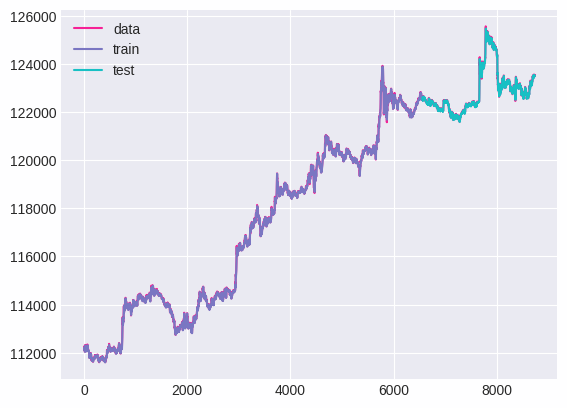

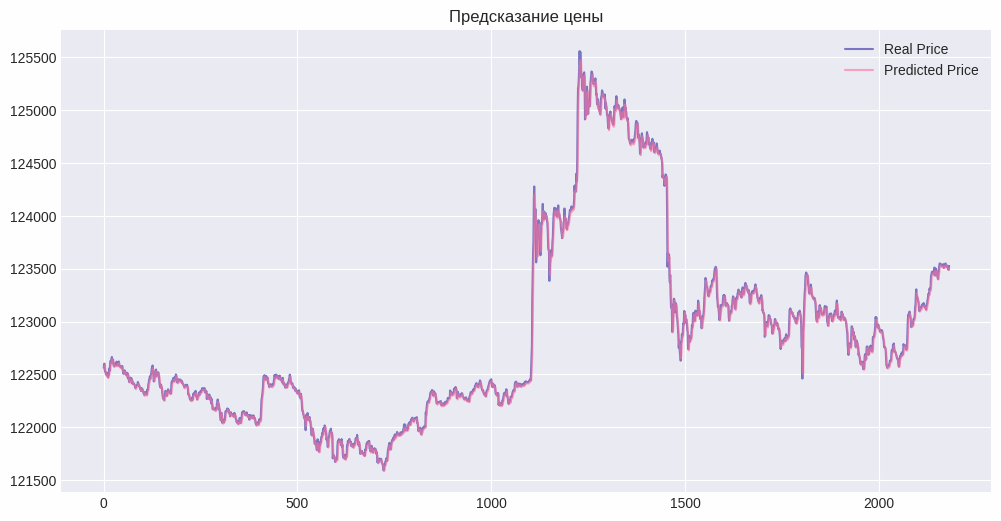

+---------+-----------------------+----------------------+
| RESULTS |         TRAIN         |         TEST         |
+---------+-----------------------+----------------------+
|   rmse  |   54.97327754562474   |  58.304699496595994  |
|   mae   |   37.327161700748015  |  34.84019626087947   |
|   mape  | 0.0003184647146131133 | 0.000282856898920923 |
+---------+-----------------------+----------------------+


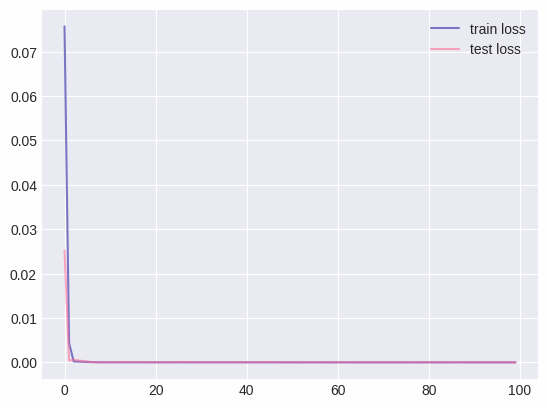

In [ ]:
step= '1m'
unit = 16
companies = 'BTC-USD'
lookback = 2
window = 10

vanilla_LSTM(step, unit, companies, lookback)

Среднее изменение: 28.85 $
Медианное изменение: 18.23 $
Стандартное отклонение изменений: 35.08 $
time = 111.65s
+---------+-----------------------+-----------------------+
| RESULTS |         TRAIN         |          TEST         |
+---------+-----------------------+-----------------------+
|   rmse  |   44.84990022067705   |   47.03786031203349   |
|   mae   |   29.636035919189453  |   26.844051361083984  |
|   mape  | 0.0002528797194827348 | 0.0002179364237235859 |
+---------+-----------------------+-----------------------+


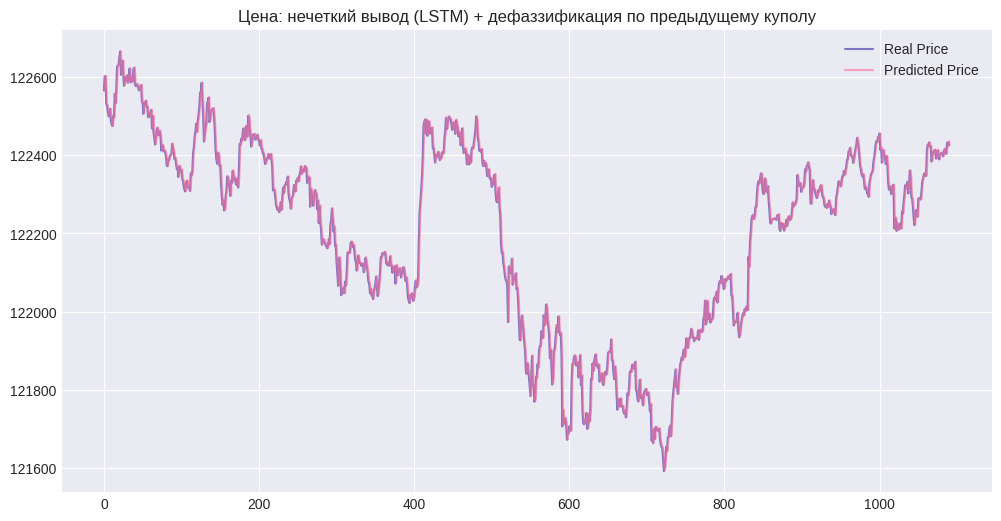

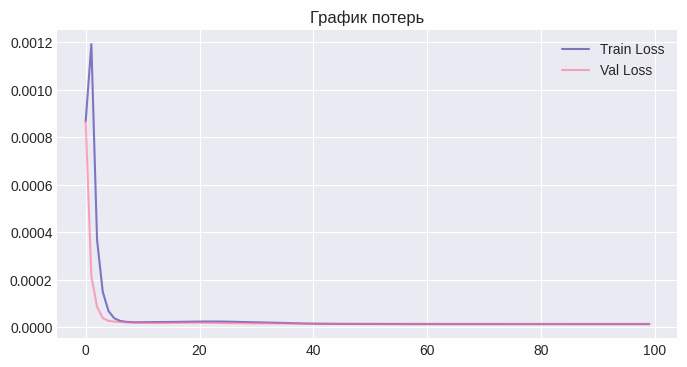

<Functional name=FuzzyLSTM_prev_defuzz, built=True>

In [ ]:
step= '1m'
unit = 16
companies = 'BTC-USD'
lookback = 2
window = 10

FuzzyLSTM(step, unit, companies, lookback, window)

Среднее изменение: 28.85 $
Медианное изменение: 18.23 $
Стандартное отклонение изменений: 35.08 $
time = 90.14s
+---------+------------------------+-----------------------+
| RESULTS |         TRAIN          |          TEST         |
+---------+------------------------+-----------------------+
|   rmse  |    44.8551324839895    |   47.01822649831526   |
|   mae   |   29.647008895874023   |   26.845844268798828  |
|   mape  | 0.00025297459797002375 | 0.0002179515577154234 |
+---------+------------------------+-----------------------+


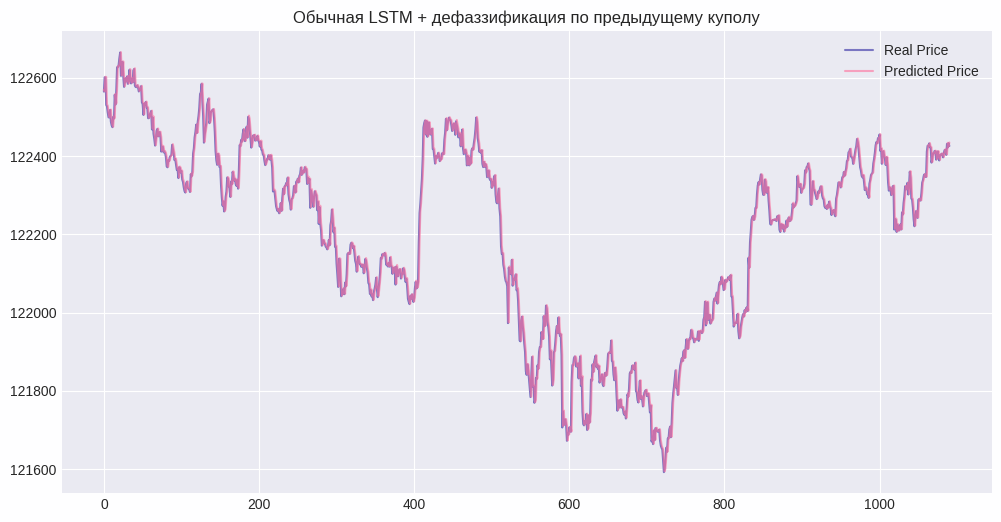

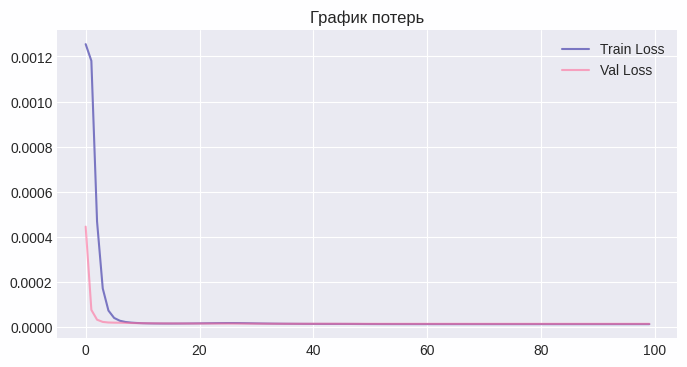

<Functional name=FuzzydataLSTM_prev_defuzz, built=True>

In [ ]:
step= '1m'
unit = 16
companies = 'BTC-USD'
lookback = 2
window = 10

Fuzzydata(step, unit, companies, lookback, window)

Среднее минутное изменение: 28.85 $
Медианное изменение: 18.23 $
Стандартное отклонение изменений: 35.08 $
time = 108.62560486793518
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
time = 0.21938681602478027


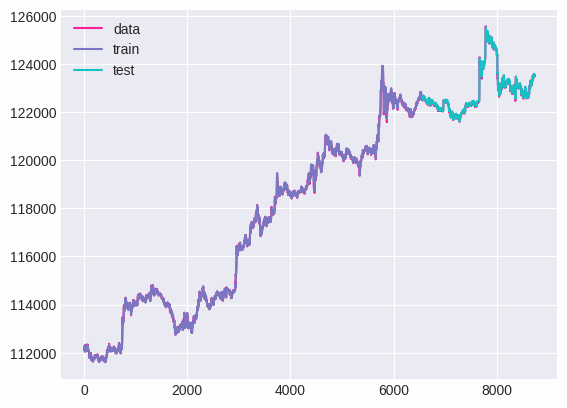

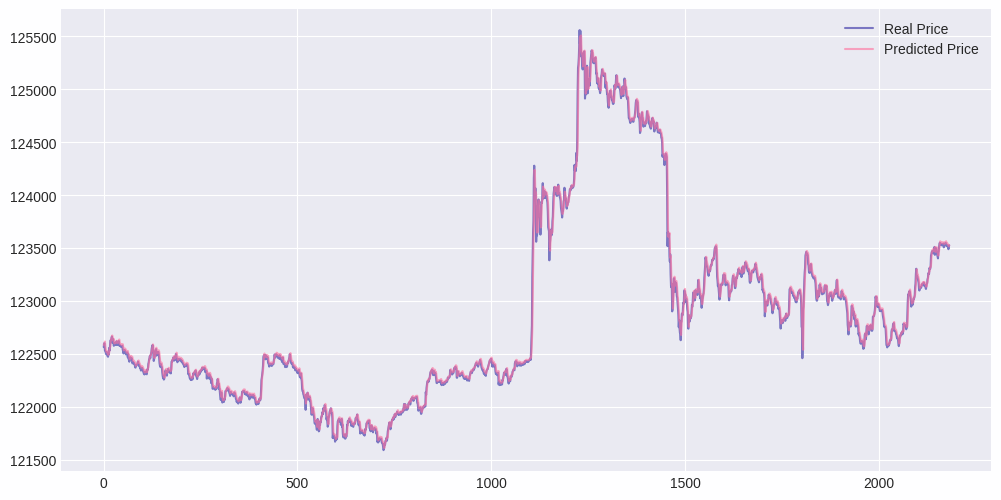

+---------+------------------------+-----------------------+
| RESULTS |         TRAIN          |          TEST         |
+---------+------------------------+-----------------------+
|   rmse  |   52.95211490545055    |   57.57765636152657   |
|   mae   |   35.87881862314978    |   35.518223202015854  |
|   mape  | 0.00030592479753172215 | 0.0002884541052055937 |
+---------+------------------------+-----------------------+


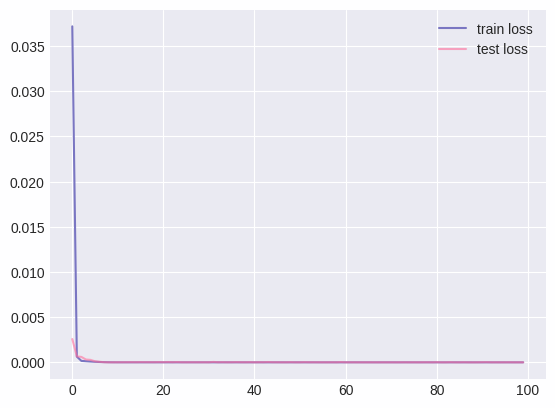

<Sequential name=sequential_4, built=True>

In [ ]:
step= '1m'
unit = 16
companies = 'BTC-USD'
lookback = 2
window = 10

parametricLSTM(step, unit, companies, lookback)

## 1h

Среднее минутное изменение: 247.22 $
Медианное изменение: 154.09 $
Стандартное отклонение изменений: 303.15 $
time = 300.6301784515381
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
time = 0.4387671947479248


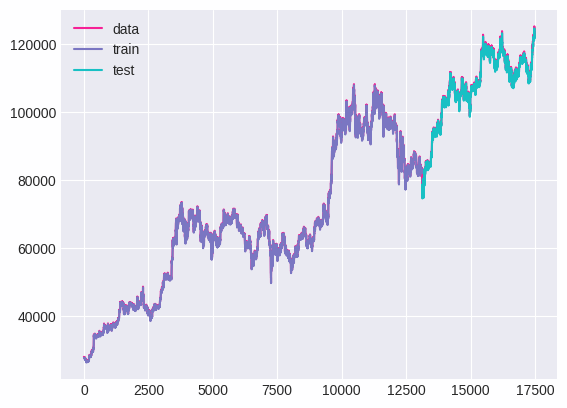

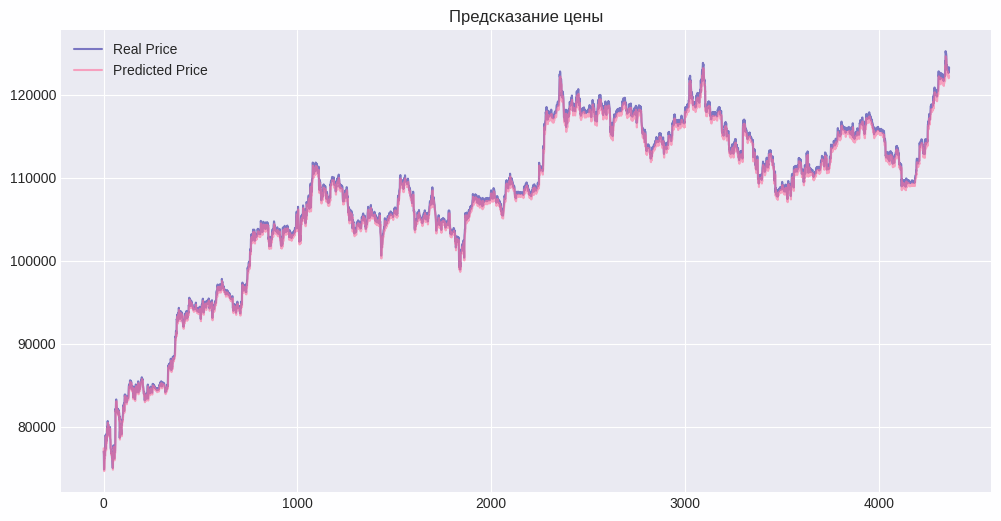

+---------+----------------------+----------------------+
| RESULTS |        TRAIN         |         TEST         |
+---------+----------------------+----------------------+
|   rmse  |  443.5242260419805   |  569.2923556339183   |
|   mae   |  314.57474096398465  |  464.7322817585376   |
|   mape  | 0.004826050273512728 | 0.004304971464914696 |
+---------+----------------------+----------------------+


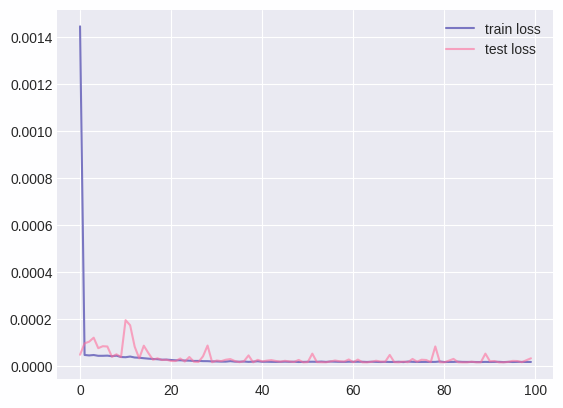

In [ ]:
step= '1h'
unit = 32
companies = 'BTC-USD'
lookback = 10
window = 10

vanilla_LSTM(step, unit, companies, lookback)

Среднее минутное изменение: 247.22 $
Медианное изменение: 154.09 $
Стандартное отклонение изменений: 303.15 $
time = 406.2686116695404
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
time = 0.4956338405609131


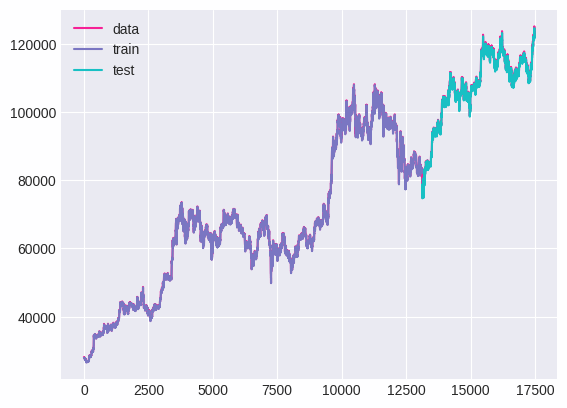

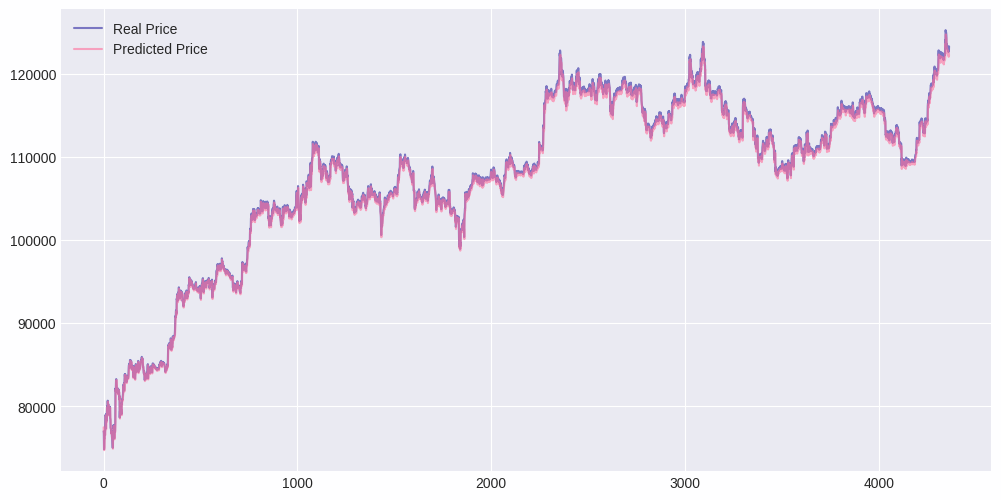

+---------+-----------------------+-----------------------+
| RESULTS |         TRAIN         |          TEST         |
+---------+-----------------------+-----------------------+
|   rmse  |   410.3982843464643   |   513.1757612253981   |
|   mae   |   268.92485109824355  |   400.4491032546412   |
|   mape  | 0.0040200372250339695 | 0.0037084088272007778 |
+---------+-----------------------+-----------------------+


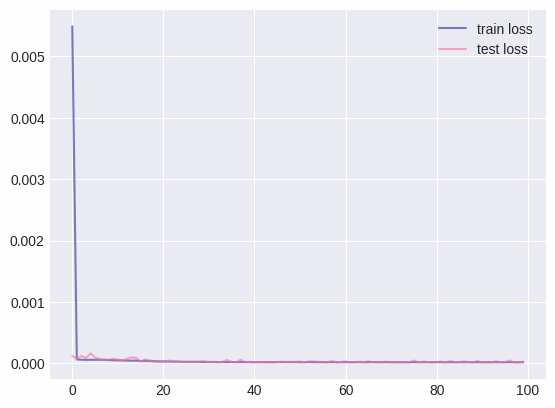

<Sequential name=sequential_7, built=True>

In [ ]:
step= '1h'
unit = 32
companies = 'BTC-USD'
lookback = 10
window = 10

parametricLSTM(step, unit, companies, lookback)

Среднее изменение: 247.22 $
Медианное изменение: 154.09 $
Стандартное отклонение изменений: 303.15 $
time = 393.45s
+---------+----------------------+-----------------------+
| RESULTS |        TRAIN         |          TEST         |
+---------+----------------------+-----------------------+
|   rmse  |  390.0251394141152   |   393.1038547572384   |
|   mae   |  241.2554168701172   |   264.9332275390625   |
|   mape  | 0.003570928005501628 | 0.0025020986795425415 |
+---------+----------------------+-----------------------+


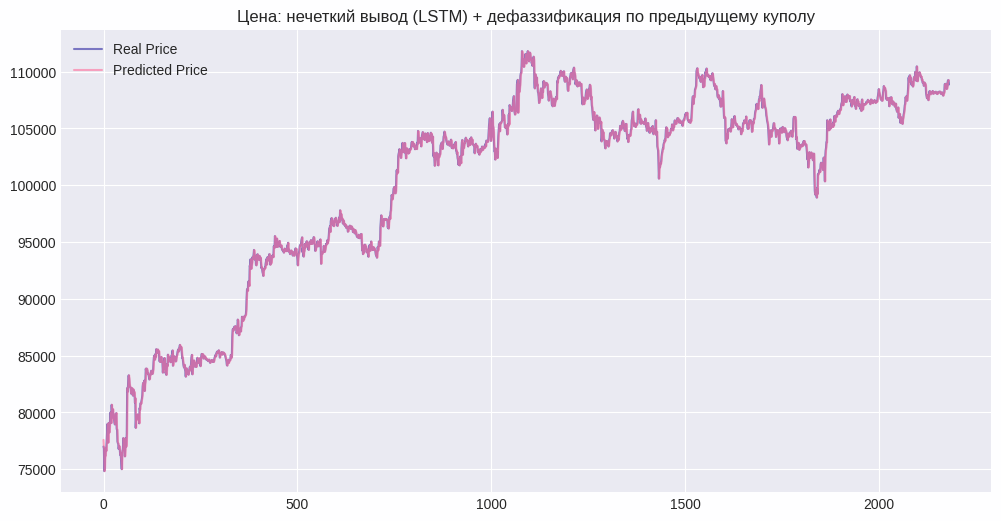

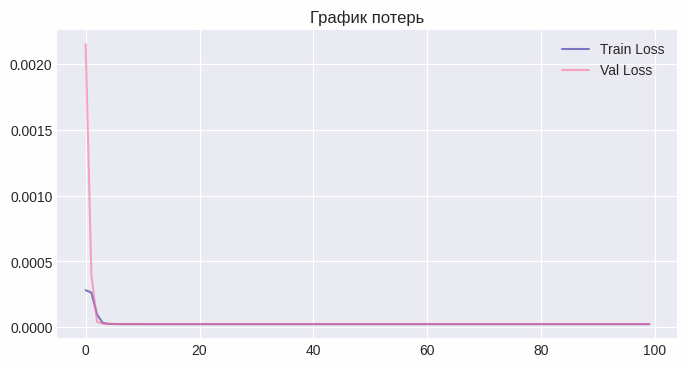

<Functional name=FuzzyLSTM_prev_defuzz, built=True>

In [ ]:
step= '1h'
unit = 32
companies = 'BTC-USD'
lookback = 10
window = 10

FuzzyLSTM(step, unit, companies, lookback, window)

Среднее изменение: 247.22 $
Медианное изменение: 154.09 $
Стандартное отклонение изменений: 303.15 $
time = 314.33s
+---------+----------------------+----------------------+
| RESULTS |        TRAIN         |         TEST         |
+---------+----------------------+----------------------+
|   rmse  |  390.0026642537202   |  394.68662410829177  |
|   mae   |  241.2794647216797   |  266.7667541503906   |
|   mape  | 0.003570219734683633 | 0.002518168417736888 |
+---------+----------------------+----------------------+


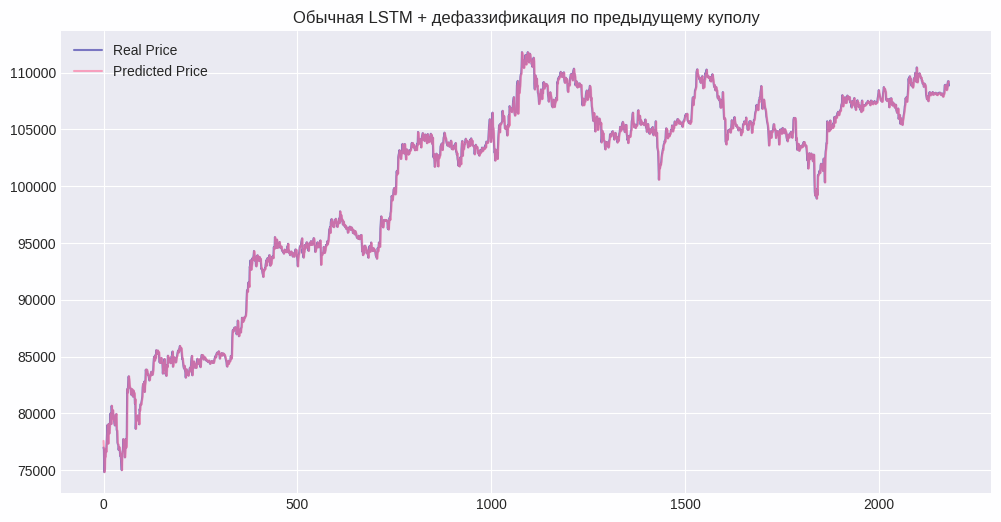

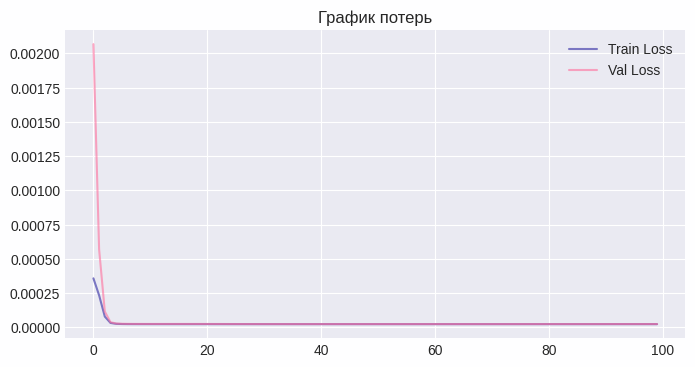

<Functional name=FuzzydataLSTM_prev_defuzz, built=True>

In [ ]:
step= '1h'
unit = 32
companies = 'BTC-USD'
lookback = 10
window = 10

Fuzzydata(step, unit, companies, lookback, window)

## 1d

Среднее минутное изменение: 532.59 $
Медианное изменение: 149.00 $
Стандартное отклонение изменений: 921.78 $
time = 40.582356452941895
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
time = 0.13816547393798828


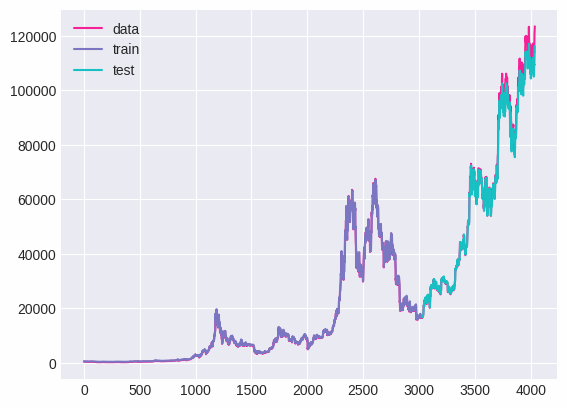

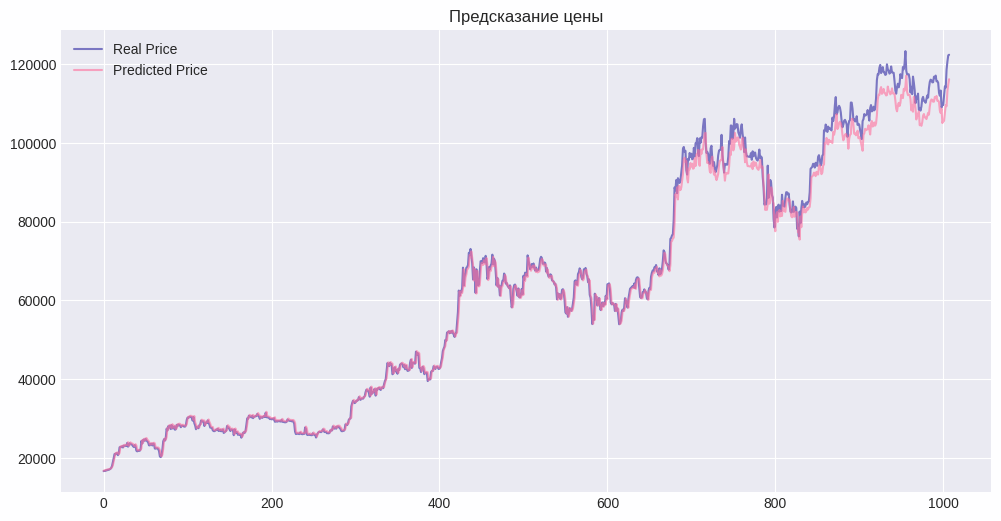

+---------+--------------------+---------------------+
| RESULTS |       TRAIN        |         TEST        |
+---------+--------------------+---------------------+
|   rmse  | 806.8517817421382  |  2564.027815612311  |
|   mae   | 424.39310056576056 |  1723.6231650700645 |
|   mape  | 0.1493615044538211 | 0.02365800018701464 |
+---------+--------------------+---------------------+


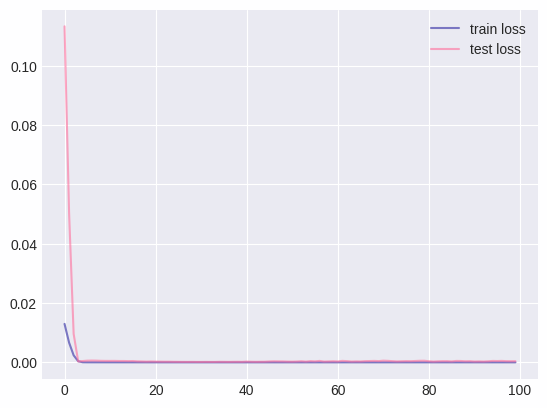

In [ ]:
step= '1d'
unit = 16
companies = 'BTC-USD'
lookback = 1
window = 10

vanilla_LSTM(step, unit, companies, lookback)

Среднее минутное изменение: 532.59 $
Медианное изменение: 149.00 $
Стандартное отклонение изменений: 921.78 $
time = 44.44122385978699
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
time = 0.20186305046081543


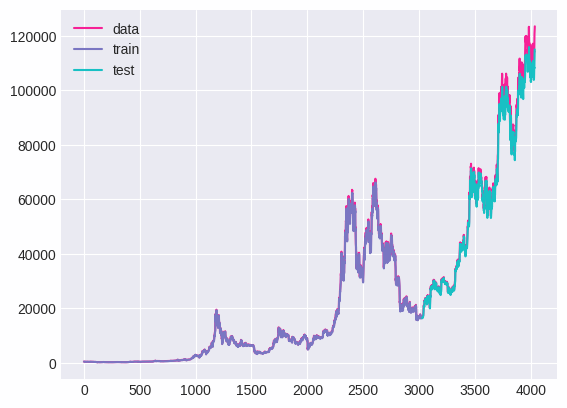

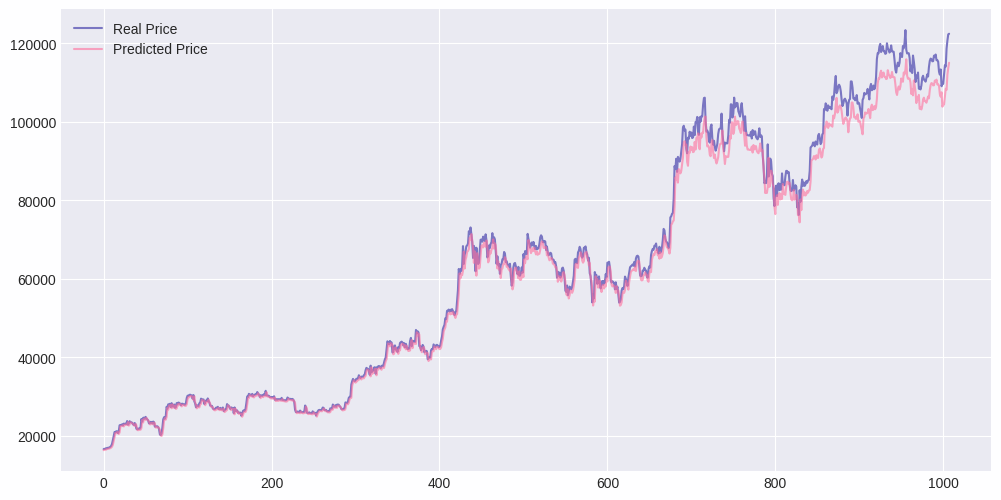

+---------+---------------------+----------------------+
| RESULTS |        TRAIN        |         TEST         |
+---------+---------------------+----------------------+
|   rmse  |  836.4934942366431  |  3180.9111120900156  |
|   mae   |  393.58706166164933 |  2204.956945025732   |
|   mape  | 0.03328340453415628 | 0.029518800931036537 |
+---------+---------------------+----------------------+


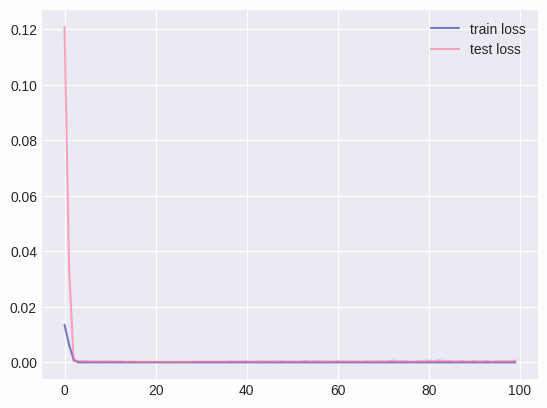

<Sequential name=sequential_10, built=True>

In [ ]:
step= '1d'
unit = 16
companies = 'BTC-USD'
lookback = 1
window = 10

parametricLSTM(step, unit, companies, lookback)

Среднее изменение: 532.59 $
Медианное изменение: 149.00 $
Стандартное отклонение изменений: 921.78 $
time = 46.51s
+---------+---------------------+---------------------+
| RESULTS |        TRAIN        |         TEST        |
+---------+---------------------+---------------------+
|   rmse  |  804.5797427850144  |  1660.9376117121317 |
|   mae   |  423.1863708496094  |  1092.2669677734375 |
|   mape  | 0.16718104481697083 | 0.01730651780962944 |
+---------+---------------------+---------------------+


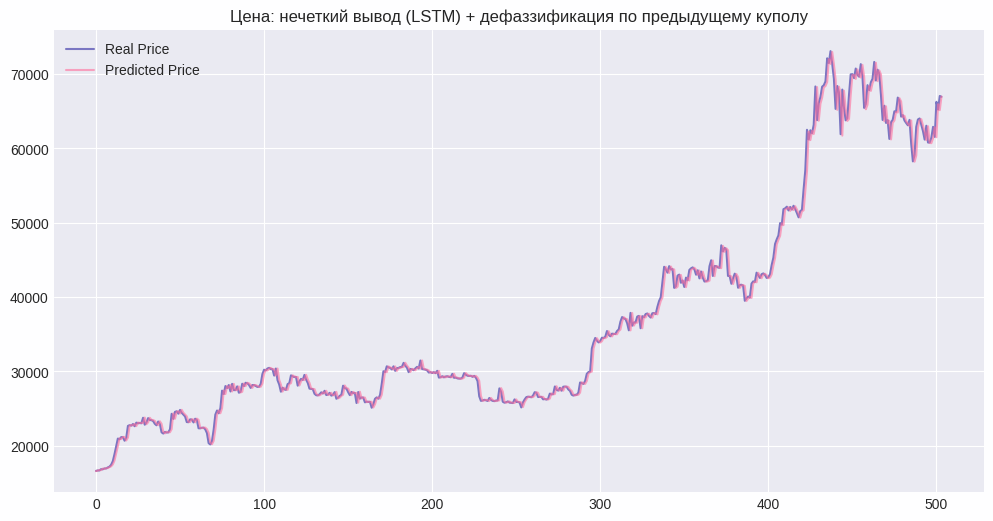

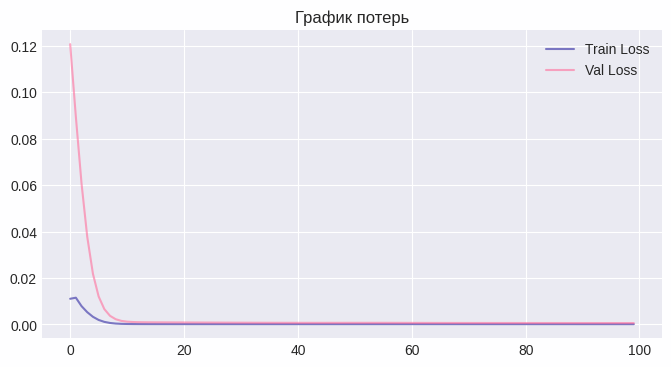

<Functional name=FuzzyLSTM_prev_defuzz, built=True>

In [ ]:
step= '1d'
unit = 16
companies = 'BTC-USD'
lookback = 1
window = 10

FuzzyLSTM(step, unit, companies, lookback, window)

Среднее изменение: 532.59 $
Медианное изменение: 149.00 $
Стандартное отклонение изменений: 921.78 $
time = 42.83s
+---------+--------------------+----------------------+
| RESULTS |       TRAIN        |         TEST         |
+---------+--------------------+----------------------+
|   rmse  | 810.5163092128375  |  1665.3083798504108  |
|   mae   | 448.1180114746094  |  1096.9317626953125  |
|   mape  | 0.2170766294002533 | 0.017346415668725967 |
+---------+--------------------+----------------------+


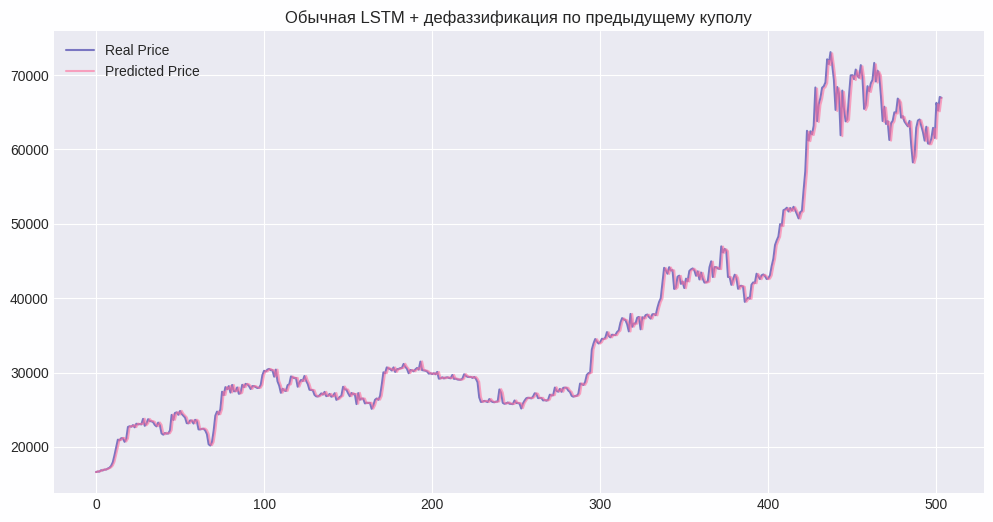

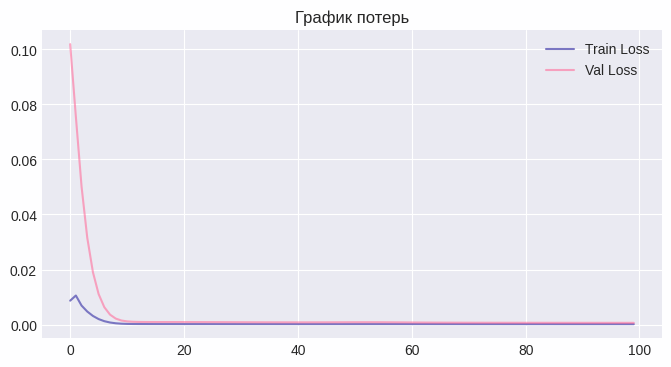

<Functional name=FuzzydataLSTM_prev_defuzz, built=True>

In [ ]:
step= '1d'
unit = 16
companies = 'BTC-USD'
lookback = 1
window = 10

Fuzzydata(step, unit, companies, lookback, window)